In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Standard imports
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
import pickle

In [3]:
# Import OpenSense modules as submodules
import sys
import os

sys.path.append(os.path.abspath("./pycomlink/"))
sys.path.append(os.path.abspath("./poligrain/src/"))
sys.path.append(os.path.abspath("./mergeplg/src/"))

import pycomlink as pycml 
import poligrain as plg

# OpenMRG analysis
OPEN FILES

In [4]:
dataset = 'OpenMRG_rainfall'
adj_path = 'data/adjusted_fields/'

ds_gauges = xr.open_dataset('data/andersson_2022_OpenMRG/gauges/openmrg_gauges.nc')     
ds_rad = xr.open_dataset("data/andersson_2022_OpenMRG/radar/openmrg_rad.nc")          
ds_cmls = xr.open_dataset("data/processed_cml_OpenMRG.nc").R_acc                              

# adding adjusted field and naming
ds_rad = ds_rad.rename({'rainfall_amount':'radar'})  
ds_rad['add_p_idw_small']=xr.open_dataset(adj_path+dataset+'_add_IDW_small.nc').rainfall_add_IDW_small
ds_rad['add_p_idw_large']=xr.open_dataset(adj_path+dataset+'_add_IDW_large.nc').rainfall_add_IDW_large

ds_rad['add_p_ok_stnd_small']=xr.open_dataset(adj_path+dataset+'_add_pBK_stnd_small.nc').rainfall_add_pBK_stnd_small
ds_rad['add_p_ok_stnd_large']=xr.open_dataset(adj_path+dataset+'_add_pBK_stnd_large.nc').rainfall_add_pBK_stnd_large
ds_rad['add_p_ok_adpt_small']=xr.open_dataset(adj_path+dataset+'_add_pBK_adpt_small.nc').rainfall_add_pBK_adpt_small
ds_rad['add_p_ok_adpt_large']=xr.open_dataset(adj_path+dataset+'_add_pBK_adpt_large.nc').rainfall_add_pBK_adpt_large
ds_rad['add_p_ok_adptf_small']=xr.open_dataset(adj_path+dataset+'_add_pBK_adptf_small.nc').rainfall_add_pBK_adpt_small
ds_rad['add_p_ok_adptf_large']=xr.open_dataset(adj_path+dataset+'_add_pBK_adptf_large.nc').rainfall_add_pBK_adpt_large

ds_rad['add_b_ok_stnd_small']=xr.open_dataset(adj_path+dataset+'_add_lBK_stnd_small.nc').rainfall_add_lBK_stnd_small
ds_rad['add_b_ok_stnd_large']=xr.open_dataset(adj_path+dataset+'_add_lBK_stnd_large.nc').rainfall_add_lBK_stnd_large
ds_rad['add_b_ok_adpt_small']=xr.open_dataset(adj_path+dataset+'_add_lBK_adpt_small.nc').rainfall_add_lBK_adpt_small
ds_rad['add_b_ok_adpt_large']=xr.open_dataset(adj_path+dataset+'_add_lBK_adpt_large.nc').rainfall_add_lBK_adpt_large
ds_rad['add_b_ok_adptf_small']=xr.open_dataset(adj_path+dataset+'_add_lBK_adptf_small.nc').rainfall_add_lBK_adpt_small
ds_rad['add_b_ok_adptf_large']=xr.open_dataset(adj_path+dataset+'_add_lBK_adptf_large.nc').rainfall_add_lBK_adpt_large

ds_rad['mul_p_idw_small']=xr.open_dataset(adj_path+dataset+'_mul_IDW_small.nc').rainfall_mul_IDW_small
ds_rad['mul_p_idw_large']=xr.open_dataset(adj_path+dataset+'_mul_IDW_large.nc').rainfall_mul_IDW_large

ds_rad['mul_p_ok_stnd_small']=xr.open_dataset(adj_path+dataset+'_mul_pBK_stnd_small.nc').rainfall_mul_pBK_stnd_small
ds_rad['mul_p_ok_stnd_large']=xr.open_dataset(adj_path+dataset+'_mul_pBK_stnd_large.nc').rainfall_mul_pBK_stnd_large
ds_rad['mul_p_ok_adpt_small']=xr.open_dataset(adj_path+dataset+'_mul_pBK_adpt_small.nc').rainfall_mul_pBK_adpt_small
ds_rad['mul_p_ok_adpt_large']=xr.open_dataset(adj_path+dataset+'_mul_pBK_adpt_large.nc').rainfall_mul_pBK_adpt_large
ds_rad['mul_p_ok_adptf_small']=xr.open_dataset(adj_path+dataset+'_mul_pBK_adptf_small.nc').rainfall_mul_pBK_adpt_small
ds_rad['mul_p_ok_adptf_large']=xr.open_dataset(adj_path+dataset+'_mul_pBK_adptf_large.nc').rainfall_mul_pBK_adpt_large

ds_rad['mul_b_ok_stnd_small']=xr.open_dataset(adj_path+dataset+'_mul_lBK_stnd_small.nc').rainfall_mul_lBK_stnd_small
ds_rad['mul_b_ok_stnd_large']=xr.open_dataset(adj_path+dataset+'_mul_lBK_stnd_large.nc').rainfall_mul_lBK_stnd_large
ds_rad['mul_b_ok_adpt_small']=xr.open_dataset(adj_path+dataset+'_mul_lBK_adpt_small.nc').rainfall_mul_lBK_adpt_small
ds_rad['mul_b_ok_adpt_large']=xr.open_dataset(adj_path+dataset+'_mul_lBK_adpt_large.nc').rainfall_mul_lBK_adpt_large
ds_rad['mul_b_ok_adptf_small']=xr.open_dataset(adj_path+dataset+'_mul_lBK_adptf_small.nc').rainfall_mul_lBK_adpt_small
ds_rad['mul_b_ok_adptf_large']=xr.open_dataset(adj_path+dataset+'_mul_lBK_adptf_large.nc').rainfall_mul_lBK_adpt_large

ds_rad['ked_p_stnd_small']=xr.open_dataset(adj_path+dataset+'_pked_stnd_small.nc').rainfall_ked_stnd_small
ds_rad['ked_p_stnd_large']=xr.open_dataset(adj_path+dataset+'_pked_stnd_large.nc').rainfall_ked_stnd_large
ds_rad['ked_p_adpt_small']=xr.open_dataset(adj_path+dataset+'_pked_adpt_small.nc').rainfall_pked_adpt_small
ds_rad['ked_p_adpt_large']=xr.open_dataset(adj_path+dataset+'_pked_adpt_large.nc').rainfall_pked_adpt_large
ds_rad['ked_p_adptf_small']=xr.open_dataset(adj_path+dataset+'_pked_adptf_small.nc').rainfall_pked_adpt_small
ds_rad['ked_p_adptf_large']=xr.open_dataset(adj_path+dataset+'_pked_adptf_large.nc').rainfall_pked_adpt_large

ds_rad['ked_b_stnd_small']=xr.open_dataset(adj_path+dataset+'_lked_stnd_small.nc').rainfall_ked_stnd_small
ds_rad['ked_b_stnd_large']=xr.open_dataset(adj_path+dataset+'_lked_stnd_large.nc').rainfall_ked_stnd_large
ds_rad['ked_b_adpt_small']=xr.open_dataset(adj_path+dataset+'_lked_adpt_small.nc').rainfall_lked_adpt_small
ds_rad['ked_b_adpt_large']=xr.open_dataset(adj_path+dataset+'_lked_adpt_large.nc').rainfall_lked_adpt_large
ds_rad['ked_b_adptf_small']=xr.open_dataset(adj_path+dataset+'_lked_adptf_small.nc').rainfall_lked_adpt_small
ds_rad['ked_b_adptf_large']=xr.open_dataset(adj_path+dataset+'_lked_adptf_large.nc').rainfall_lked_adpt_large

In [5]:
# Fields used for exploring variogram and neighborhood selection
all_fields = ['radar', 
              
              'add_p_idw_small', 'add_p_idw_large', 
              'add_p_ok_stnd_small', 'add_p_ok_stnd_large', 'add_p_ok_adpt_small', 'add_p_ok_adpt_large', 'add_p_ok_adptf_small', 'add_p_ok_adptf_large', 
              'add_b_ok_stnd_small', 'add_b_ok_stnd_large', 'add_b_ok_adpt_small', 'add_b_ok_adpt_large', 'add_b_ok_adptf_small', 'add_b_ok_adptf_large',

              'mul_p_idw_small', 'mul_p_idw_large', 
              'mul_p_ok_stnd_small', 'mul_p_ok_stnd_large', 'mul_p_ok_adpt_small', 'mul_p_ok_adpt_large', 'mul_p_ok_adptf_small', 'mul_p_ok_adptf_large', 
              'mul_b_ok_stnd_small', 'mul_b_ok_stnd_large', 'mul_b_ok_adpt_small', 'mul_b_ok_adpt_large', 'mul_b_ok_adptf_small', 'mul_b_ok_adptf_large',

              'ked_p_stnd_small', 'ked_p_stnd_large', 'ked_p_adpt_small', 'ked_p_adpt_large', 'ked_p_adptf_small', 'ked_p_adptf_large',
              'ked_b_stnd_small', 'ked_b_stnd_large', 'ked_b_adpt_small', 'ked_b_adpt_large', 'ked_b_adptf_small', 'ked_b_adptf_large',
]

# Fields used for the rest of the study, keeping the same order as previous version
target_fields = ['radar', 
              
                  'add_p_idw_large', 
                  'add_p_ok_adptf_large', 
                  'add_b_ok_adptf_large',

                  'ked_p_adptf_large',
                  'ked_b_adptf_large',
                 
                  'mul_p_idw_large', 
                  'mul_p_ok_adptf_large', 
                  'mul_b_ok_adptf_large',

]

COMPARE RADAR AND RAIN GAUGES

In [6]:
# RAINFALL FIELDS AT THE RAIN GAUGES
get_grid_at_points = plg.spatial.GridAtPoints(
    da_gridded_data=ds_rad.isel(time = 0), 
    da_point_data=ds_gauges.isel(time = 0),
    nnear=1,
    stat="best" 
)

for field in all_fields:
    ds_gauges[field] = get_grid_at_points(
        da_gridded_data=ds_rad[field],
        da_point_data=ds_gauges.rainfall_amount,  
    )

In [7]:
# # # Outlier removal
# for field in all_fields:
#     ds_gauges[field] = xr.where(ds_gauges[field] > (ds_gauges['radar'] + 100), ds_gauges['radar'] + 100, ds_gauges[field])
        
# #     elif field.split('_')[0] == 'mul':
# #         ds_gauges[field] = xr.where(ds_gauges[field] > (ds_gauges['radar']+ 15), ds_gauges['radar']*15, ds_gauges[field])
# #         ds_gauges[field] = xr.where(ds_gauges[field] < (ds_gauges['radar']*0.1), ds_gauges['radar']*0.1, ds_gauges[field])

# #     elif field.split('_')[0] == 'ked':
# #         ds_gauges[field] = xr.where(ds_gauges[field] > (ds_gauges['radar'] + 10), ds_gauges['radar'] + 10, ds_gauges[field])
# #         ds_gauges[field] = xr.where(ds_gauges[field] < (ds_gauges['radar'] - 10), ds_gauges['radar'] - 10, ds_gauges[field])
# #     else:
# #         print('error')

for field in all_fields:
    ds_gauges[field] = xr.where(ds_gauges[field] > 150, 150, ds_gauges[field])


In [8]:
# COMPUTE METRICS
threshold = 0.2

for field in target_fields:
        if field == 'radar':
            metric = pd.DataFrame([plg.validation.calculate_rainfall_metrics(
                reference=ds_gauges.rainfall_amount.values.flatten(),
                estimate=ds_gauges[field].values.flatten(),
                ref_thresh=threshold,
                est_thresh=threshold,
            )]) 
            metric['dataset'] = 'OpenMRG'
            metric['method'] = field
            result = metric
        else:
            metric = pd.DataFrame([plg.validation.calculate_rainfall_metrics(
                reference=ds_gauges.rainfall_amount.values.flatten(),
                estimate=ds_gauges[field].values.flatten(),
                ref_thresh=threshold,
                est_thresh=threshold,
            )]) 
            metric['dataset'] = 'OpenMRG'
            metric['method'] = field
            result = pd.concat([result, metric])

result.to_csv('metrics_OpenMRG.csv')

In [9]:
# COMPUTE METRICS
threshold = 0.2

result_all = np.zeros([len(all_fields), ds_gauges.time.size, 4])
for f, field in enumerate(all_fields): 
    # Load data, faster than looking up time for each loop 
    ground = ds_gauges.rainfall_amount.data 
    target = ds_gauges[field].data
    
    for t, time in enumerate(ds_gauges.time):
        
        metric =  plg.validation.calculate_rainfall_metrics(
            reference=ground[t, :].ravel(),
            estimate=target[t, :].ravel(),
            ref_thresh=threshold,
            est_thresh=threshold,
        ) 

        # Get metrics
        result_all[f, t, 0] = metric['pearson_correlation_coefficient']
        result_all[f, t, 1] = metric['root_mean_square_error']
        result_all[f, t, 2] = metric['mean_absolute_error']
        result_all[f, t, 3] = metric['percent_bias']

/home/erlend/miniforge3/envs/radar_adjustment_intercomparison/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/erlend/miniforge3/envs/radar_adjustment_intercomparison/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/erlend/git/radar_adjustment_intercomparison/poligrain/src/poligrain/validation.py:192: RuntimeWarning: Mean of empty slice.
  FP_r_mean = estimate[reference_dry & estimate_wet].mean()
/home/erlend/miniforge3/envs/radar_adjustment_intercomparison/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/erlend/miniforge3/envs/radar_adjustment_intercomparison/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c 

In [10]:
with open('metrics_all_OpenMRG.pkl', 'wb') as f:
    pickle.dump(result_all, f)

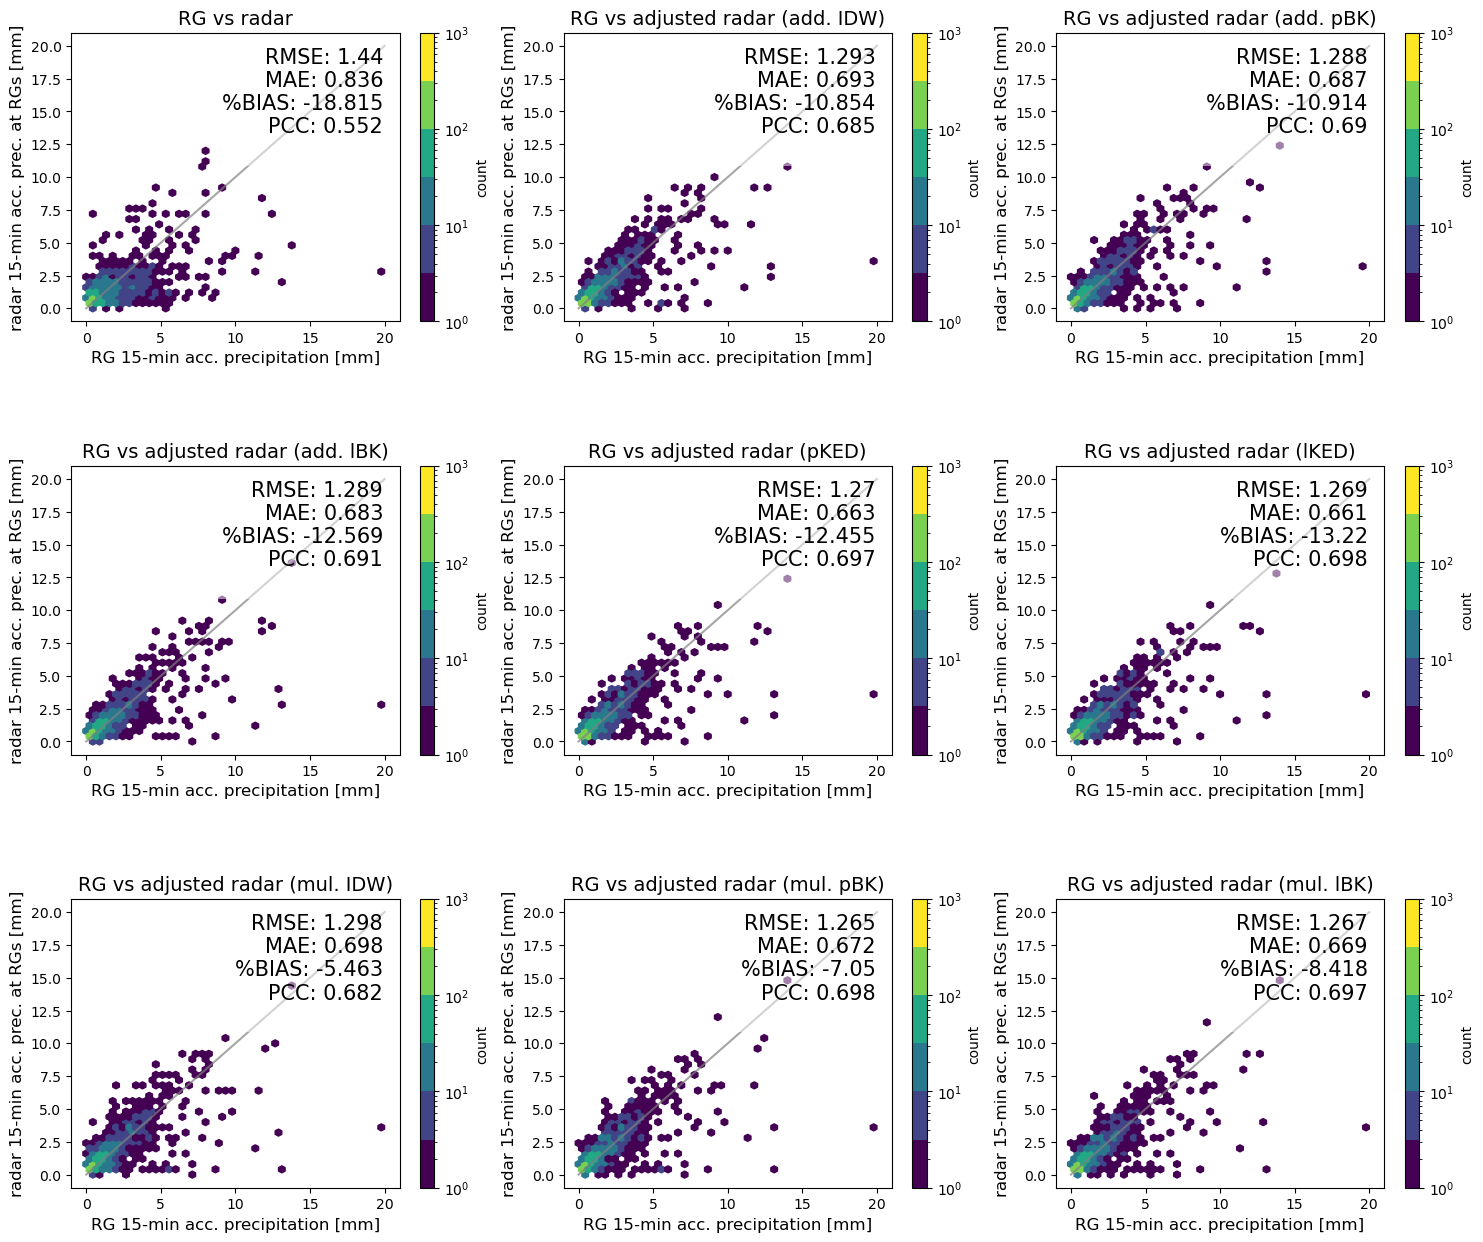

In [11]:
titles = ['RG vs radar', 
          
          'RG vs adjusted radar (add. IDW)', 
          'RG vs adjusted radar (add. pBK)',
          'RG vs adjusted radar (add. lBK)',
          
          'RG vs adjusted radar (pKED)', 
          'RG vs adjusted radar (lKED)',
          
          'RG vs adjusted radar (mul. IDW)', 
          'RG vs adjusted radar (mul. pBK)', 
          'RG vs adjusted radar (mul. lBK)',
         ]

fig, ax = plt.subplots(3, 3, figsize=(18, 15)) 
fax = ax.flatten()
for i in range(len(fax)):

        hx = plg.validation.plot_hexbin(
            ds_gauges.rainfall_amount.values.flatten(),
            ds_gauges[target_fields[i]].values.flatten(),
            ref_thresh=0.2,
            est_thresh=0.2,
            ax=fax[i],
        )

        metric = pd.DataFrame([plg.validation.calculate_rainfall_metrics(
            reference=ds_gauges.rainfall_amount.values.flatten(),
            estimate=ds_gauges[target_fields[i]].values.flatten(),
            ref_thresh=0.2,
            est_thresh=0.2)])

        fax[i].text(
            0.95, 0.95,                 
            "RMSE: "+str(round(metric.root_mean_square_error.values[0], 3))+'\n'+
            "MAE: "+str(round(metric.mean_absolute_error.values[0], 3))+'\n'+
            "%BIAS: "+str(round(metric.percent_bias.values[0], 3))+'\n'+
            "PCC: "+str(round(metric.pearson_correlation_coefficient.values[0], 3))+'\n',             
            transform=fax[i].transAxes,     
            ha='right', va='top',       
            fontsize=15, color='black',  
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')  
        )

        fax[i].set_ylabel('radar 15-min acc. prec. at RGs [mm]', fontsize=12)
        fax[i].set_xlabel('RG 15-min acc. precipitation [mm]', fontsize=12)
        fax[i].set_title(titles[i], fontsize=14)

plt.subplots_adjust(hspace=0.5)

INTENSITY ANALYSIS

In [12]:
# prec_classes [lower limit, upper limit, class name (int)]
prec_classes = np.array([[0.2,2.5, '[0.2,2.5['], [2.5, 10, '[2.5,10['], [10, 50, '[10,50['], [50, 1000, '>= 50']])
threshold = 0.2

start = 0
for item in prec_classes:
    data = xr.where((ds_gauges.rainfall_amount >= float(item[0]))&(ds_gauges.rainfall_amount < float(item[1])), ds_gauges, np.nan) 
    for field in target_fields:
        if start == 0:
            metric = pd.DataFrame([plg.validation.calculate_rainfall_metrics(
                reference=data.rainfall_amount.values.flatten(),
                estimate=data[field].values.flatten(),
                ref_thresh=threshold,
                est_thresh=threshold,
            )]) 
            metric['class'] = [item[2]]
            metric['field'] = [field]
            ndata = data.rainfall_amount.values.flatten()
            metric['ndata'] = len(ndata[~np.isnan(ndata)])
            result = metric
            start += 1
        else:
            metric = pd.DataFrame([plg.validation.calculate_rainfall_metrics(
                reference=data.rainfall_amount.values.flatten(),
                estimate=data[field].values.flatten(),
                ref_thresh=threshold,
                est_thresh=threshold,
            )]) 
            metric['class'] = [item[2]]
            metric['field'] = [field]
            ndata = data.rainfall_amount.values.flatten()
            metric['ndata'] = len(ndata[~np.isnan(ndata)])
            result = pd.concat([result, metric])

result.to_csv('intensity_analysis_OpenMRG.csv')

/home/erlend/git/radar_adjustment_intercomparison/poligrain/src/poligrain/validation.py:192: RuntimeWarning: Mean of empty slice.
  FP_r_mean = estimate[reference_dry & estimate_wet].mean()
/home/erlend/miniforge3/envs/radar_adjustment_intercomparison/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/erlend/git/radar_adjustment_intercomparison/poligrain/src/poligrain/validation.py:192: RuntimeWarning: Mean of empty slice.
  FP_r_mean = estimate[reference_dry & estimate_wet].mean()
/home/erlend/miniforge3/envs/radar_adjustment_intercomparison/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/erlend/git/radar_adjustment_intercomparison/poligrain/src/poligrain/validation.py:192: RuntimeWarning: Mean of empty slice.
  FP_r_mean = estimate[reference_dry & estimate_wet].mean(

## OpenRainER analysis
OPEN FILES

In [13]:
dataset = 'OpenRainER'
adj_path = 'data/adjusted_fields/'

ds_gauges = xr.open_dataset('data/covi_2024_OpenRainER/AWS_rainfall.nc')        
ds_rad = xr.open_dataset("data/covi_2024_OpenRainER/openrainer_radar.nc")       
ds_cmls = xr.open_dataset("data/processed_cml_OpenRainER.nc").R_acc                               

# adding adjusted field and naming
ds_rad = ds_rad.rename({'rainfall_amount':'radar'})  
ds_rad['add_p_idw_small']=xr.open_dataset(adj_path+dataset+'_rainfall_add_IDW_small.nc').rainfall_add_IDW_small
ds_rad['add_p_idw_large']=xr.open_dataset(adj_path+dataset+'_rainfall_add_IDW_large.nc').rainfall_add_IDW_large

ds_rad['add_p_ok_stnd_small']=xr.open_dataset(adj_path+dataset+'_rainfall_add_pBK_stnd_small.nc').rainfall_add_pBK_stnd_small
ds_rad['add_p_ok_stnd_large']=xr.open_dataset(adj_path+dataset+'_rainfall_add_pBK_stnd_large.nc').rainfall_add_pBK_stnd_large
ds_rad['add_p_ok_adpt_small']=xr.open_dataset(adj_path+dataset+'_rainfall_add_pBK_adpt_small.nc').rainfall_add_pBK_adpt_small
ds_rad['add_p_ok_adpt_large']=xr.open_dataset(adj_path+dataset+'_rainfall_add_pBK_adpt_large.nc').rainfall_add_pBK_adpt_large
ds_rad['add_p_ok_adptf_small']=xr.open_dataset(adj_path+dataset+'_rainfall_add_pBK_adptf_small.nc').rainfall_add_pBK_adpt_small
ds_rad['add_p_ok_adptf_large']=xr.open_dataset(adj_path+dataset+'_rainfall_add_pBK_adptf_large.nc').rainfall_add_pBK_adpt_large

ds_rad['add_b_ok_stnd_small']=xr.open_dataset(adj_path+dataset+'_rainfall_add_lBK_stnd_small.nc').rainfall_add_lBK_stnd_small
ds_rad['add_b_ok_stnd_large']=xr.open_dataset(adj_path+dataset+'_rainfall_add_lBK_stnd_large.nc').rainfall_add_lBK_stnd_large
ds_rad['add_b_ok_adpt_small']=xr.open_dataset(adj_path+dataset+'_rainfall_add_lBK_adpt_small.nc').rainfall_add_lBK_adpt_small
ds_rad['add_b_ok_adpt_large']=xr.open_dataset(adj_path+dataset+'_rainfall_add_lBK_adpt_large.nc').rainfall_add_lBK_adpt_large
ds_rad['add_b_ok_adptf_small']=xr.open_dataset(adj_path+dataset+'_rainfall_add_lBK_adptf_small.nc').rainfall_add_lBK_adpt_small
ds_rad['add_b_ok_adptf_large']=xr.open_dataset(adj_path+dataset+'_rainfall_add_lBK_adptf_large.nc').rainfall_add_lBK_adpt_large

ds_rad['mul_p_idw_small']=xr.open_dataset(adj_path+dataset+'_rainfall_mul_IDW_small.nc').rainfall_mul_IDW_small
ds_rad['mul_p_idw_large']=xr.open_dataset(adj_path+dataset+'_rainfall_mul_IDW_large.nc').rainfall_mul_IDW_large

ds_rad['mul_p_ok_stnd_small']=xr.open_dataset(adj_path+dataset+'_rainfall_mul_pBK_stnd_small.nc').rainfall_mul_pBK_stnd_small
ds_rad['mul_p_ok_stnd_large']=xr.open_dataset(adj_path+dataset+'_rainfall_mul_pBK_stnd_large.nc').rainfall_mul_pBK_stnd_large
ds_rad['mul_p_ok_adpt_small']=xr.open_dataset(adj_path+dataset+'_rainfall_mul_pBK_adpt_small.nc').rainfall_mul_pBK_adpt_small
ds_rad['mul_p_ok_adpt_large']=xr.open_dataset(adj_path+dataset+'_rainfall_mul_pBK_adpt_large.nc').rainfall_mul_pBK_adpt_large
ds_rad['mul_p_ok_adptf_small']=xr.open_dataset(adj_path+dataset+'_rainfall_mul_pBK_adptf_small.nc').rainfall_mul_pBK_adpt_small
ds_rad['mul_p_ok_adptf_large']=xr.open_dataset(adj_path+dataset+'_rainfall_mul_pBK_adptf_large.nc').rainfall_mul_pBK_adpt_large

ds_rad['mul_b_ok_stnd_small']=xr.open_dataset(adj_path+dataset+'_rainfall_mul_lBK_stnd_small.nc').rainfall_mul_lBK_stnd_small
ds_rad['mul_b_ok_stnd_large']=xr.open_dataset(adj_path+dataset+'_rainfall_mul_lBK_stnd_large.nc').rainfall_mul_lBK_stnd_large
ds_rad['mul_b_ok_adpt_small']=xr.open_dataset(adj_path+dataset+'_rainfall_mul_lBK_adpt_small.nc').rainfall_mul_lBK_adpt_small
ds_rad['mul_b_ok_adpt_large']=xr.open_dataset(adj_path+dataset+'_rainfall_mul_lBK_adpt_large.nc').rainfall_mul_lBK_adpt_large
ds_rad['mul_b_ok_adptf_small']=xr.open_dataset(adj_path+dataset+'_rainfall_mul_lBK_adptf_small.nc').rainfall_mul_lBK_adpt_small
ds_rad['mul_b_ok_adptf_large']=xr.open_dataset(adj_path+dataset+'_rainfall_mul_lBK_adptf_large.nc').rainfall_mul_lBK_adpt_large

ds_rad['ked_p_stnd_small']=xr.open_dataset(adj_path+dataset+'_rainfall_pked_stnd_small.nc').rainfall_ked_stnd_small
ds_rad['ked_p_stnd_large']=xr.open_dataset(adj_path+dataset+'_rainfall_pked_stnd_large.nc').rainfall_ked_stnd_large
ds_rad['ked_p_adpt_small']=xr.open_dataset(adj_path+dataset+'_rainfall_pked_adpt_small.nc').rainfall_pked_adpt_small
ds_rad['ked_p_adpt_large']=xr.open_dataset(adj_path+dataset+'_rainfall_pked_adpt_large.nc').rainfall_pked_adpt_large
ds_rad['ked_p_adptf_small']=xr.open_dataset(adj_path+dataset+'_rainfall_pked_adptf_small.nc').rainfall_pked_adpt_small
ds_rad['ked_p_adptf_large']=xr.open_dataset(adj_path+dataset+'_rainfall_pked_adptf_large.nc').rainfall_pked_adpt_large

ds_rad['ked_b_stnd_small']=xr.open_dataset(adj_path+dataset+'_rainfall_lked_stnd_small.nc').rainfall_ked_stnd_small
ds_rad['ked_b_stnd_large']=xr.open_dataset(adj_path+dataset+'_rainfall_lked_stnd_large.nc').rainfall_ked_stnd_large
ds_rad['ked_b_adpt_small']=xr.open_dataset(adj_path+dataset+'_rainfall_lked_adpt_small.nc').rainfall_lked_adpt_small
ds_rad['ked_b_adpt_large']=xr.open_dataset(adj_path+dataset+'_rainfall_lked_adpt_large.nc').rainfall_lked_adpt_large
ds_rad['ked_b_adptf_small']=xr.open_dataset(adj_path+dataset+'_rainfall_lked_adptf_small.nc').rainfall_lked_adpt_small
ds_rad['ked_b_adptf_large']=xr.open_dataset(adj_path+dataset+'_rainfall_lked_adptf_large.nc').rainfall_lked_adpt_large


In [14]:
# Fields used for exploring variogram and neighborhood selection
all_fields = ['radar', 
              
              'add_p_idw_small', 'add_p_idw_large', 
              'add_p_ok_stnd_small', 'add_p_ok_stnd_large', 'add_p_ok_adpt_small', 'add_p_ok_adpt_large', 'add_p_ok_adptf_small', 'add_p_ok_adptf_large', 
              'add_b_ok_stnd_small', 'add_b_ok_stnd_large', 'add_b_ok_adpt_small', 'add_b_ok_adpt_large', 'add_b_ok_adptf_small', 'add_b_ok_adptf_large',

              'mul_p_idw_small', 'mul_p_idw_large', 
              'mul_p_ok_stnd_small', 'mul_p_ok_stnd_large', 'mul_p_ok_adpt_small', 'mul_p_ok_adpt_large', 'mul_p_ok_adptf_small', 'mul_p_ok_adptf_large', 
              'mul_b_ok_stnd_small', 'mul_b_ok_stnd_large', 'mul_b_ok_adpt_small', 'mul_b_ok_adpt_large', 'mul_b_ok_adptf_small', 'mul_b_ok_adptf_large',

              'ked_p_stnd_small', 'ked_p_stnd_large', 'ked_p_adpt_small', 'ked_p_adpt_large', 'ked_p_adptf_small', 'ked_p_adptf_large',
              'ked_b_stnd_small', 'ked_b_stnd_large', 'ked_b_adpt_small', 'ked_b_adpt_large', 'ked_b_adptf_small', 'ked_b_adptf_large',
]

# Fields used for the rest of the study, keeping the same order as previous version
target_fields = ['radar', 
              
                  'add_p_idw_large', 
                  'add_p_ok_adptf_large', 
                  'add_b_ok_adptf_large',

                  'ked_p_adptf_large',
                  'ked_b_adptf_large',
                 
                  'mul_p_idw_large', 
                  'mul_p_ok_adptf_large', 
                  'mul_b_ok_adptf_large',

]

In [15]:
# RAINFALL FIELDS AT THE RAIN GAUGES
get_grid_at_points = plg.spatial.GridAtPoints(
    da_gridded_data=ds_rad.isel(time = 0), 
    da_point_data=ds_gauges.isel(time = 0),
    nnear=1,
    stat="best" 
)

for field in all_fields:
    ds_gauges[field] = get_grid_at_points(
        da_gridded_data=ds_rad[field],
        da_point_data=ds_gauges.rainfall_amount,  
    )

In [16]:
# # # Outlier removal
# for field in all_fields:
#     ds_gauges[field] = xr.where(ds_gauges[field] > (ds_gauges['radar'] + 100), ds_gauges['radar'] + 100, ds_gauges[field])
        
# #     elif field.split('_')[0] == 'mul':
# #         ds_gauges[field] = xr.where(ds_gauges[field] > (ds_gauges['radar']+ 15), ds_gauges['radar']*15, ds_gauges[field])
# #         ds_gauges[field] = xr.where(ds_gauges[field] < (ds_gauges['radar']*0.1), ds_gauges['radar']*0.1, ds_gauges[field])

# #     elif field.split('_')[0] == 'ked':
# #         ds_gauges[field] = xr.where(ds_gauges[field] > (ds_gauges['radar'] + 10), ds_gauges['radar'] + 10, ds_gauges[field])
# #         ds_gauges[field] = xr.where(ds_gauges[field] < (ds_gauges['radar'] - 10), ds_gauges['radar'] - 10, ds_gauges[field])
# #     else:
# #         print('error')

for field in all_fields:
    ds_gauges[field] = xr.where(ds_gauges[field] > 150, 150, ds_gauges[field])


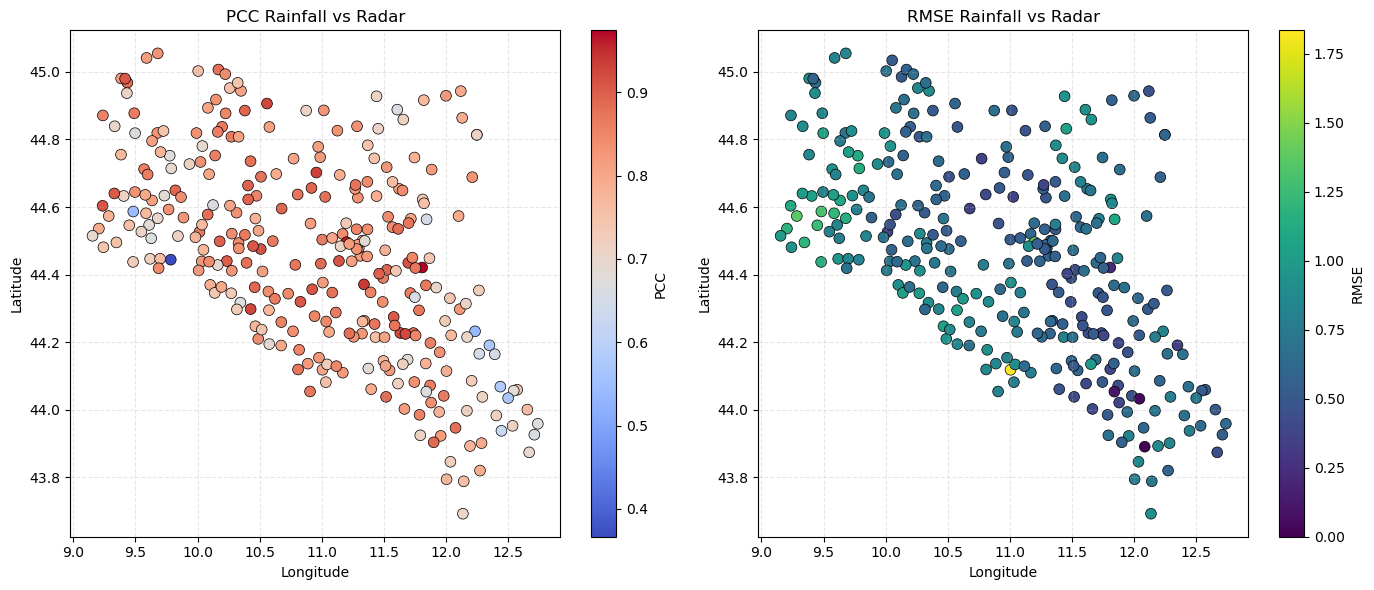

In [17]:
rmse = np.sqrt(
    ((ds_gauges.rainfall_amount - ds_gauges.radar) ** 2).mean(dim="time")
)
pcc = xr.corr(ds_gauges["rainfall_amount"], ds_gauges["radar"], dim="time")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot PCC ---
sc1 = axes[0].scatter(
    pcc.lon,
    pcc.lat,
    c=pcc,
    s=60,
    cmap="coolwarm",
    edgecolors="k",
    linewidth=0.5,
)

axes[0].set_title("PCC Rainfall vs Radar")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].grid(True, linestyle="--", alpha=0.3)
plt.colorbar(sc1, ax=axes[0], label="PCC")


# --- Plot RMSE ---
sc2 = axes[1].scatter(
    rmse.lon,
    rmse.lat,
    c=rmse,
    s=60,
    cmap="viridis",
    edgecolors="k",
    linewidth=0.5,
)

axes[1].set_title("RMSE Rainfall vs Radar")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].grid(True, linestyle="--", alpha=0.3)
plt.colorbar(sc2, ax=axes[1], label="RMSE")

plt.tight_layout()
plt.show()

In [18]:
# COMPUTE METRICS
threshold = 0.2

for field in target_fields:
        if field == 'radar':
            metric = pd.DataFrame([plg.validation.calculate_rainfall_metrics(
                reference=ds_gauges.rainfall_amount.values.flatten(),
                estimate=ds_gauges[field].values.flatten(),
                ref_thresh=threshold,
                est_thresh=threshold,
            )]) 
            metric['dataset'] = 'OpenRainER'
            metric['method'] = field
            result = metric
        else:
            metric = pd.DataFrame([plg.validation.calculate_rainfall_metrics(
                reference=ds_gauges.rainfall_amount.values.flatten(),
                estimate=ds_gauges[field].values.flatten(),
                ref_thresh=threshold,
                est_thresh=threshold,
            )]) 
            metric['dataset'] = 'OpenRainER'
            metric['method'] = field
            result = pd.concat([result, metric])

result.to_csv('metrics_OpenRainER.csv')

In [19]:
# COMPUTE METRICS
threshold = 0.2

result_all = np.zeros([len(all_fields), ds_gauges.time.size, 4])
for f, field in enumerate(all_fields): 
    # Load data, faster than looking up time for each loop 
    ground = ds_gauges.rainfall_amount.data 
    target = ds_gauges[field].data
    
    for t, time in enumerate(ds_gauges.time):
        
        metric =  plg.validation.calculate_rainfall_metrics(
            reference=ground[:, t].ravel(),
            estimate=target[:, t].ravel(),
            ref_thresh=threshold,
            est_thresh=threshold,
        )

        # Get metrics
        result_all[f, t, 0] = metric['pearson_correlation_coefficient']
        result_all[f, t, 1] = metric['root_mean_square_error']
        result_all[f, t, 2] = metric['mean_absolute_error']
        result_all[f, t, 3] = metric['percent_bias']
        
with open('metrics_all_OpenRainER.pkl', 'wb') as f:
    pickle.dump(result_all, f)

/home/erlend/miniforge3/envs/radar_adjustment_intercomparison/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/erlend/git/radar_adjustment_intercomparison/poligrain/src/poligrain/validation.py:192: RuntimeWarning: Mean of empty slice.
  FP_r_mean = estimate[reference_dry & estimate_wet].mean()
/home/erlend/miniforge3/envs/radar_adjustment_intercomparison/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/home/erlend/miniforge3/envs/radar_adjustment_intercomparison/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/erlend/miniforge3/envs/radar_adjustment_intercomparison/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in div

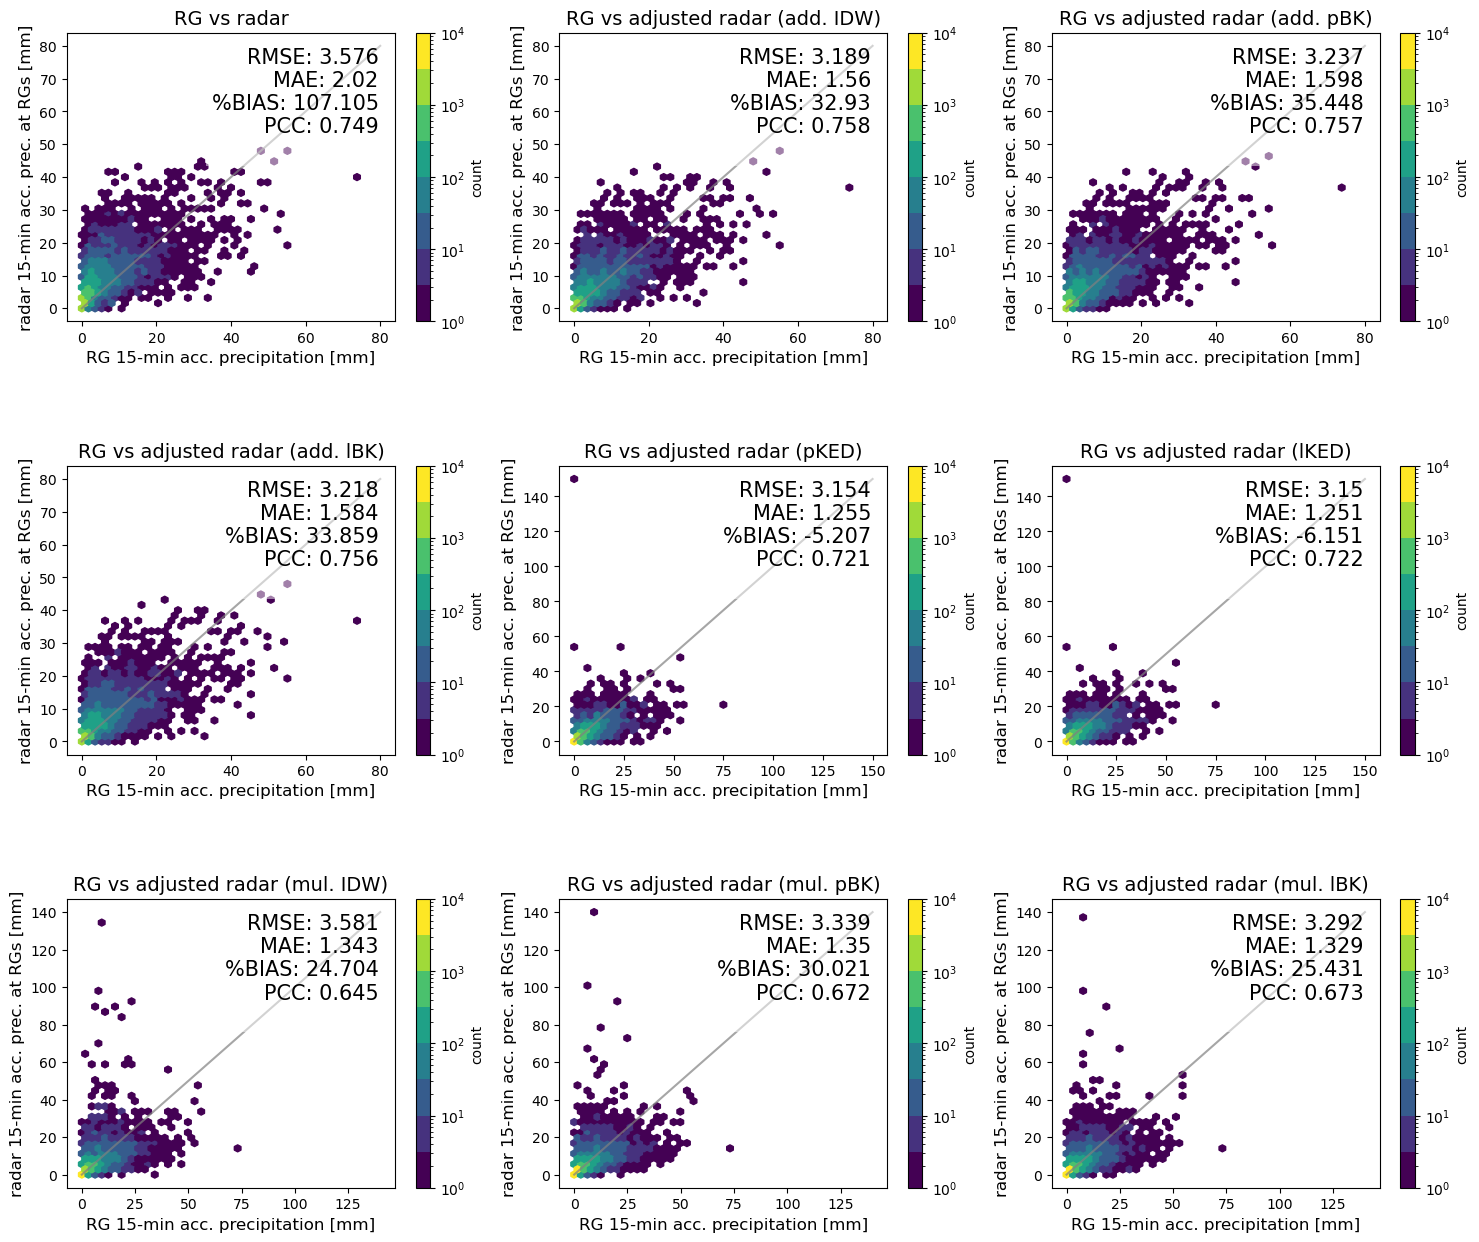

In [20]:
titles = ['RG vs radar', 'RG vs adjusted radar (add. IDW)', 'RG vs adjusted radar (add. pBK)',
          'RG vs adjusted radar (add. lBK)', 'RG vs adjusted radar (pKED)', 'RG vs adjusted radar (lKED)',
          'RG vs adjusted radar (mul. IDW)', 'RG vs adjusted radar (mul. pBK)', 'RG vs adjusted radar (mul. lBK)']

fig, ax = plt.subplots(3, 3, figsize=(18, 15)) 
fax = ax.flatten()
for i in range(len(fax)):

        hx = plg.validation.plot_hexbin(
            ds_gauges.rainfall_amount.values.flatten(),
            ds_gauges[target_fields[i]].values.flatten(),
            ref_thresh=0.2,
            est_thresh=0.2,
            ax=fax[i],
        )

        metric = pd.DataFrame([plg.validation.calculate_rainfall_metrics(
            reference=ds_gauges.rainfall_amount.values.flatten(),
            estimate=ds_gauges[target_fields[i]].values.flatten(),
            ref_thresh=0.2,
            est_thresh=0.2)])

        fax[i].text(
            0.95, 0.95,                 
            "RMSE: "+str(round(metric.root_mean_square_error.values[0], 3))+'\n'+
            "MAE: "+str(round(metric.mean_absolute_error.values[0], 3))+'\n'+
            "%BIAS: "+str(round(metric.percent_bias.values[0], 3))+'\n'+
            "PCC: "+str(round(metric.pearson_correlation_coefficient.values[0], 3))+'\n',             
            transform=fax[i].transAxes,     
            ha='right', va='top',       
            fontsize=15, color='black',  
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')  
        )

        fax[i].set_ylabel('radar 15-min acc. prec. at RGs [mm]', fontsize=12)
        fax[i].set_xlabel('RG 15-min acc. precipitation [mm]', fontsize=12)
        fax[i].set_title(titles[i], fontsize=14)

plt.subplots_adjust(hspace=0.5)

DISTANCE ANALYSIS

In [21]:
distances = np.arange(2000, 32000, 2000)
threshold = 0.2

start = 0
for max_distance in distances:
    closest_neigbors = plg.spatial.get_closest_points_to_line(
        ds_cmls, ds_gauges.rainfall_amount, max_distance=max_distance, n_closest=len(ds_gauges.id.values)
    )

    closest_rgs = closest_neigbors.neighbor_id.values.flatten()
    ds_closegauges = ds_gauges.sel(id=np.unique(closest_rgs[closest_rgs!= None]))

    for field in target_fields:

        metric = pd.DataFrame([plg.validation.calculate_rainfall_metrics(
            reference=ds_closegauges.rainfall_amount.values.flatten(),
            estimate=ds_closegauges[field].values.flatten(),
            ref_thresh=threshold,
            est_thresh=threshold,
        )])
        metric['distance'] = [max_distance]
        metric['field'] = [field]
        metric['n_gauges'] = [len(ds_closegauges.id.values)]

        if start == 0:
            result_metric = metric
            start += 1
        else:
            result_metric = pd.concat([result_metric, metric])

result_metric.to_csv('metrics_distance.csv')

/tmp/ipykernel_41668/2317479980.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Blues_r", len(distances))
/tmp/ipykernel_41668/2317479980.py:78: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax1.boxplot(rmse_groups, labels=labels, showfliers=False, patch_artist=True)
/tmp/ipykernel_41668/2317479980.py:90: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax2.boxplot(pcc_groups, labels=labels, showfliers=False, patch_artist=True)


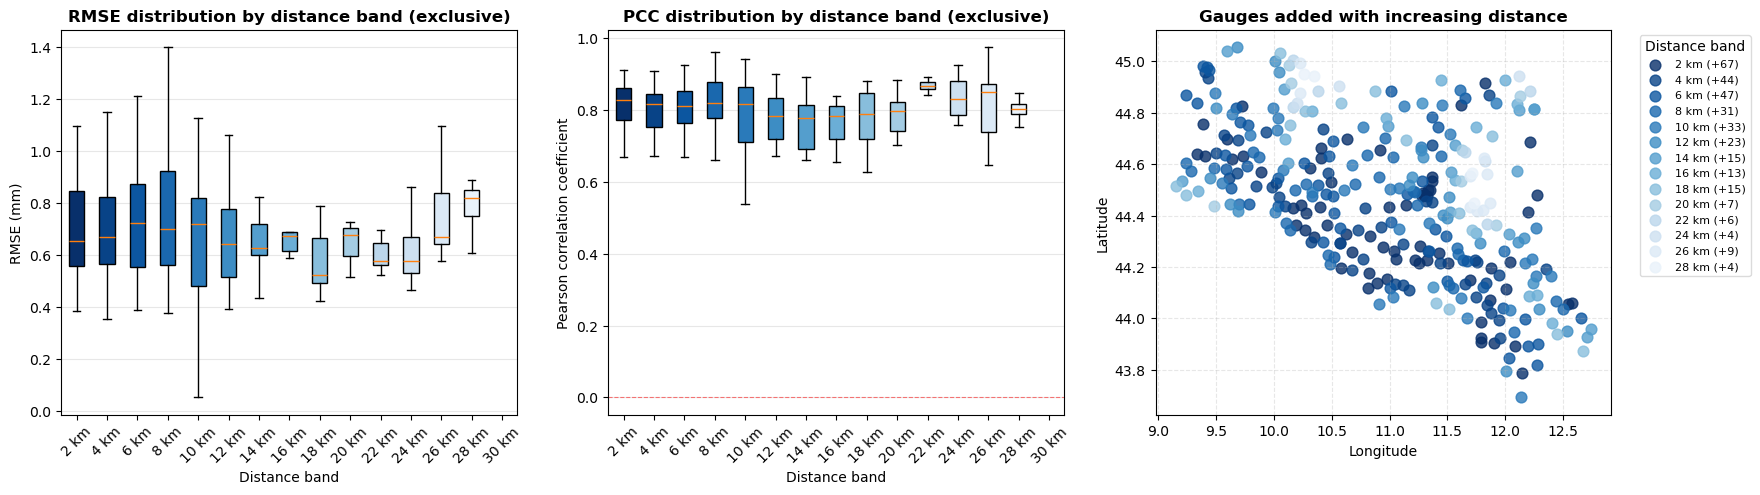

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import matplotlib.cm as cm

# --- PARAMETERS ---
distances = np.arange(2000, 32000, 2000)  # in meters
cmap = cm.get_cmap("Blues_r", len(distances))

# --- CALCULATE RMSE AND PCC ---
rmse = np.sqrt(((ds_gauges.rainfall_amount - ds_gauges.radar)**2).mean(dim="time"))
pcc = xr.corr(ds_gauges["rainfall_amount"], ds_gauges["radar"], dim="time")

# --- GROUP GAUGES BY DISTANCE BANDS (EXCLUSIVE) ---
groups = {}
all_seen_ids = set()

for i, max_distance in enumerate(distances):
    try:
        closest_neighbors = plg.spatial.get_closest_points_to_line(
            ds_cmls,
            ds_gauges.rainfall_amount,
            max_distance=max_distance,
            n_closest=len(ds_gauges.id.values)
        )
        
        closest_rgs = closest_neighbors.neighbor_id.values.flatten()
        # Remove None values and get unique IDs
        valid_ids = [id_val for id_val in closest_rgs if id_val is not None]
        current_ids = set(valid_ids)
        
        # Get only NEW gauges not seen in previous distance bands
        new_ids = current_ids - all_seen_ids
        
        dist_km = int(max_distance / 1000)
        groups[dist_km] = list(new_ids)
        
        # Update the set of all seen IDs
        all_seen_ids.update(new_ids)
        
    except Exception as e:
        print(f"Error at distance {max_distance}m: {e}")
        dist_km = int(max_distance / 1000)
        groups[dist_km] = []

# --- PREPARE DATA FOR BOXPLOTS ---
labels = [f"{km} km" for km in sorted(groups.keys())]
rmse_groups = []
pcc_groups = []

for km in sorted(groups.keys()):
    gauge_ids = groups[km]
    if len(gauge_ids) > 0:
        # Get RMSE and PCC values for gauges in this distance group
        rmse_vals = rmse.sel(id=gauge_ids).values
        pcc_vals = pcc.sel(id=gauge_ids).values
        
        # Remove NaN values
        rmse_vals = rmse_vals[~np.isnan(rmse_vals)]
        pcc_vals = pcc_vals[~np.isnan(pcc_vals)]
        
        rmse_groups.append(rmse_vals if len(rmse_vals) > 0 else [])
        pcc_groups.append(pcc_vals if len(pcc_vals) > 0 else [])
    else:
        rmse_groups.append([])
        pcc_groups.append([])

# --- PLOT BOX PLOTS AND SPATIAL MAP ---
fig = plt.figure(figsize=(20, 5))

# Create grid for subplots: 2 boxplots + 1 map
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1])
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# RMSE subplot
bp1 = ax1.boxplot(rmse_groups, labels=labels, showfliers=False, patch_artist=True)
ax1.set_title("RMSE distribution by distance band (exclusive)", fontsize=12, fontweight='bold')
ax1.set_ylabel("RMSE (mm)", fontsize=10)
ax1.set_xlabel("Distance band", fontsize=10)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# Color the boxes
for patch, i in zip(bp1['boxes'], range(len(bp1['boxes']))):
    patch.set_facecolor(cmap(i))

# PCC subplot
bp2 = ax2.boxplot(pcc_groups, labels=labels, showfliers=False, patch_artist=True)
ax2.set_title("PCC distribution by distance band (exclusive)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Pearson correlation coefficient", fontsize=10)
ax2.set_xlabel("Distance band", fontsize=10)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=0.8)

# Color the boxes
for patch, i in zip(bp2['boxes'], range(len(bp2['boxes']))):
    patch.set_facecolor(cmap(i))

# Spatial map subplot
all_seen_ids_map = set()

for i, max_distance in enumerate(distances):
    try:
        closest_neighbors = plg.spatial.get_closest_points_to_line(
            ds_cmls,
            ds_gauges.rainfall_amount,
            max_distance=max_distance,
            n_closest=len(ds_gauges.id.values)
        )
        
        closest_rgs = closest_neighbors.neighbor_id.values.flatten()
        valid_ids = [id_val for id_val in closest_rgs if id_val is not None]
        current_ids = set(valid_ids)
        
        # Get only NEW gauges
        new_ids = current_ids - all_seen_ids_map
        
        if new_ids:
            ds_new = ds_gauges.sel(id=list(new_ids))
            color = cmap(i)
            
            ax3.scatter(
                ds_new.lon,
                ds_new.lat,
                alpha=0.8,
                s=60,
                color=color,
                label=f"{max_distance/1000:.0f} km (+{len(new_ids)})"
            )
        
        all_seen_ids_map.update(new_ids)
        
    except Exception as e:
        print(f"Error plotting distance {max_distance}m: {e}")

ax3.set_xlabel("Longitude", fontsize=10)
ax3.set_ylabel("Latitude", fontsize=10)
ax3.set_title("Gauges added with increasing distance", fontsize=12, fontweight='bold')
ax3.grid(True, linestyle="--", alpha=0.3)
ax3.legend(title="Distance band", framealpha=0.7, fontsize=8, bbox_to_anchor=(1.05, 1), loc='upper left')

INTENSITY ANALYSIS

In [23]:
# prec_classes [lower limit, upper limit, class name (int)]
prec_classes = np.array([[0.2,2.5, '[0.2,2.5['], [2.5, 10, '[2.5,10['], [10, 50, '[10,50['], [50, 1000, '>= 50']])
threshold = 0.2

start = 0
for item in prec_classes:
    data = xr.where((ds_gauges.rainfall_amount >= float(item[0]))&(ds_gauges.rainfall_amount < float(item[1])), ds_gauges, np.nan) 
    for field in target_fields:
        if start == 0:
            metric = pd.DataFrame([plg.validation.calculate_rainfall_metrics(
                reference=data.rainfall_amount.values.flatten(),
                estimate=data[field].values.flatten(),
                ref_thresh=threshold,
                est_thresh=threshold,
            )]) 
            metric['class'] = [item[2]]
            metric['field'] = [field]
            ndata = data.rainfall_amount.values.flatten()
            metric['ndata'] = len(ndata[~np.isnan(ndata)])
            result = metric
            start += 1
        else:
            metric = pd.DataFrame([plg.validation.calculate_rainfall_metrics(
                reference=data.rainfall_amount.values.flatten(),
                estimate=data[field].values.flatten(),
                ref_thresh=threshold,
                est_thresh=threshold,
            )]) 
            metric['class'] = [item[2]]
            metric['field'] = [field]
            ndata = data.rainfall_amount.values.flatten()
            metric['ndata'] = len(ndata[~np.isnan(ndata)])
            result = pd.concat([result, metric])

result.to_csv('intensity_analysis_OpenRainER.csv')

/home/erlend/git/radar_adjustment_intercomparison/poligrain/src/poligrain/validation.py:192: RuntimeWarning: Mean of empty slice.
  FP_r_mean = estimate[reference_dry & estimate_wet].mean()
/home/erlend/miniforge3/envs/radar_adjustment_intercomparison/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/home/erlend/git/radar_adjustment_intercomparison/poligrain/src/poligrain/validation.py:192: RuntimeWarning: Mean of empty slice.
  FP_r_mean = estimate[reference_dry & estimate_wet].mean()
/home/erlend/miniforge3/envs/radar_adjustment_intercomparison/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/erlend/git/radar_adjustment_intercomparison/poligrain/src/poligrain/validation.py:192: RuntimeWarning: Mean of empty slice.
  FP_r_mean = estimate[reference_dry & estimate_wet].mean()
/home

RANGE CHECK ANALYSIS

In [24]:
# COMPUTE METRICS
threshold = 0.2

for field in fields:
        if field == 'radar':
            metric = pd.DataFrame([plg.validation.calculate_rainfall_metrics(
                reference=ds_gauges.rainfall_amount.values.flatten(),
                estimate=ds_gauges[field].values.flatten(),
                ref_thresh=threshold,
                est_thresh=threshold,
            )]) 
            metric['dataset'] = 'OpenRainER'
            metric['method'] = field
            result = metric
        else:
            metric = pd.DataFrame([plg.validation.calculate_rainfall_metrics(
                reference=ds_gauges.rainfall_amount.values.flatten(),
                estimate=ds_gauges[field].values.flatten(),
                ref_thresh=threshold,
                est_thresh=threshold,
            )]) 
            metric['dataset'] = 'OpenRainER'
            metric['method'] = field
            result = pd.concat([result, metric])

result.to_csv('metrics_OpenRainER_cc.csv')

NameError: name 'fields' is not defined

In [ ]:
# COMPUTE METRICS
threshold = 0.2

for field in fields:
        if field == 'radar':
            metric = pd.DataFrame([plg.validation.calculate_rainfall_metrics(
                reference=ds_gauges.rainfall_amount.values.flatten(),
                estimate=ds_gauges[field].values.flatten(),
                ref_thresh=threshold,
                est_thresh=threshold,
            )]) 
            metric['dataset'] = 'OpenRainER'
            metric['method'] = field
            result = metric
        else:
            metric = pd.DataFrame([plg.validation.calculate_rainfall_metrics(
                reference=ds_gauges.rainfall_amount.values.flatten(),
                estimate=ds_gauges[field].values.flatten(),
                ref_thresh=threshold,
                est_thresh=threshold,
            )]) 
            metric['dataset'] = 'OpenRainER'
            metric['method'] = field
            result = pd.concat([result, metric])

result.to_csv('metrics_OpenRainER_nc.csv')